# ShopSmart Retail EDA
**The Darko Method 2026 | Module 06**

Answering four business questions for the Head of Merchandising:
- **Q1** — Which product categories and customer segments generate the most revenue?
- **Q2** — Where do cancellations concentrate?
- **Q3** — Does a higher rating correlate with higher spend?
- **Q4** — Which transactions are statistically unusual?

In [1]:
import sys, pathlib
root = pathlib.Path().resolve().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from src.eda_engine       import EDAEngine
from src.anomaly_detector import AnomalyDetector

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# Load and profile the data
engine = EDAEngine()
engine.load().profile().group_analysis().correlation()

df = engine.df
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
df.head(3)

2026-05-24 21:37:17 [INFO] EDAEngine initialised — industry: retail_data
2026-05-24 21:37:17 [INFO] [EDA] Loading: processed-data.csv
2026-05-24 21:37:17 [INFO] [EDA] Loaded 50,000 rows × 22 columns
2026-05-24 21:37:17 [INFO] [EDA] Column types: 3 numeric, 14 categorical
2026-05-24 21:37:17 [INFO] [EDA] Computing dataset profile...
2026-05-24 21:37:17 [INFO] [EDA] Profile complete — 50,000 rows | 7.48% nulls
2026-05-24 21:37:17 [INFO] [EDA] Running group analysis...
2026-05-24 21:37:17 [INFO] [EDA] Group analysis: 2 grouping variable(s)
2026-05-24 21:37:17 [INFO] [EDA] Computing correlation...
2026-05-24 21:37:17 [INFO] [EDA] Correlation: 0 meaningful pairs (threshold |r| > 0.3)


Loaded 50,000 rows × 22 columns


,order_id,order_date,total_amount,order_status,customer_id,first_name,last_name,customer_email,customer_city,customer_country,...,product_name,product_category,product_price,seller_id,owner_name,seller_country,seller_category,review_id,rating,review_text
0,41344,2024-12-31,760.72,Delivered,9282,Joseph,Smith,joseph.smith52@gmail.com,Houston,Nigeria,...,Product Food 420,Electronics,372.84,875,Robert Jones,Australia,Beauty,6709.0,4.0,Delivery was fast and the product works perfec...
1,29416,2024-12-31,84.94,Cancelled,4870,Charles,Martin,charles.martin48@gmail.com,Singapore,UK,...,Product Auto 559,Home,755.87,480,Susan Garcia,France,Sports,968.0,4.0,The product looks different from the pictures....
2,15540,2024-12-31,1564.68,Processing,5838,Mary,Martin,mary.martin8@gmail.com,Dubai,France,...,Product Fashion 944,Food,415.65,324,Fatima Asante,Canada,Toys,3759.0,3.0,Delivery was fast and the product works perfec...


---
## Chart 1 — Revenue by Product Category
**Q1:** Which `product_category` generates the highest `total_amount` per order?

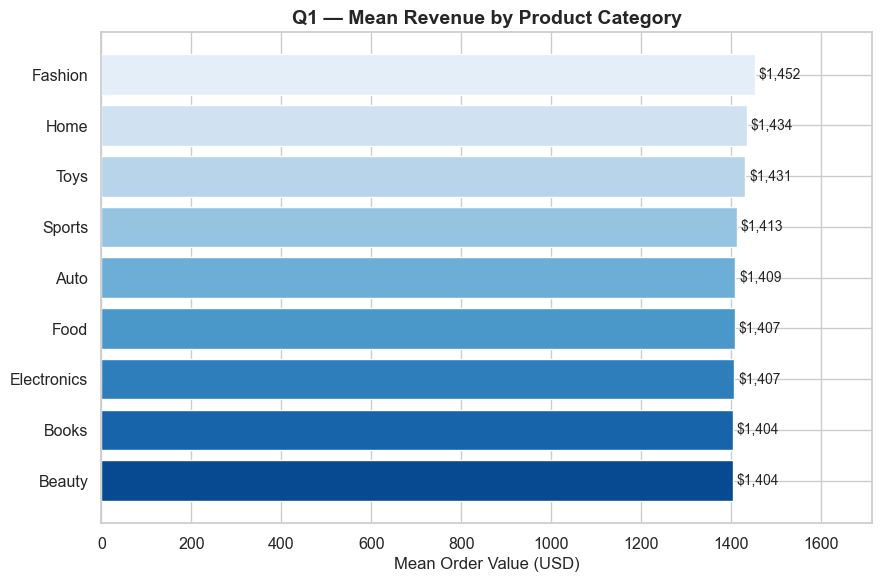


Top category: Fashion  ($1,452)
Bottom category: Beauty  ($1,404)
Spread (max-min): $48


In [2]:
agg = (
    df.groupby('product_category')['total_amount']
    .mean()
    .sort_values(ascending=True)
    .round(2)
)

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('Blues_r', len(agg))
bars = ax.barh(agg.index, agg.values, color=palette, edgecolor='white')

ax.set_xlabel('Mean Order Value (USD)', fontsize=12)
ax.set_title('Q1 — Mean Revenue by Product Category', fontsize=14, fontweight='bold')

for bar, val in zip(bars, agg.values):
    ax.text(val + 8, bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}', va='center', fontsize=10)

ax.set_xlim(0, agg.max() * 1.18)
plt.tight_layout()
plt.show()

print(f'\nTop category: {agg.idxmax()}  (${agg.max():,.0f})')
print(f'Bottom category: {agg.idxmin()}  (${agg.min():,.0f})')
print(f'Spread (max-min): ${agg.max()-agg.min():,.0f}')

---
## Chart 2 — Order Status Breakdown
**Q2:** What proportion of orders are Cancelled? Where do cancellations concentrate?

TypeError: <lambda>() got an unexpected keyword argument 'include_groups'

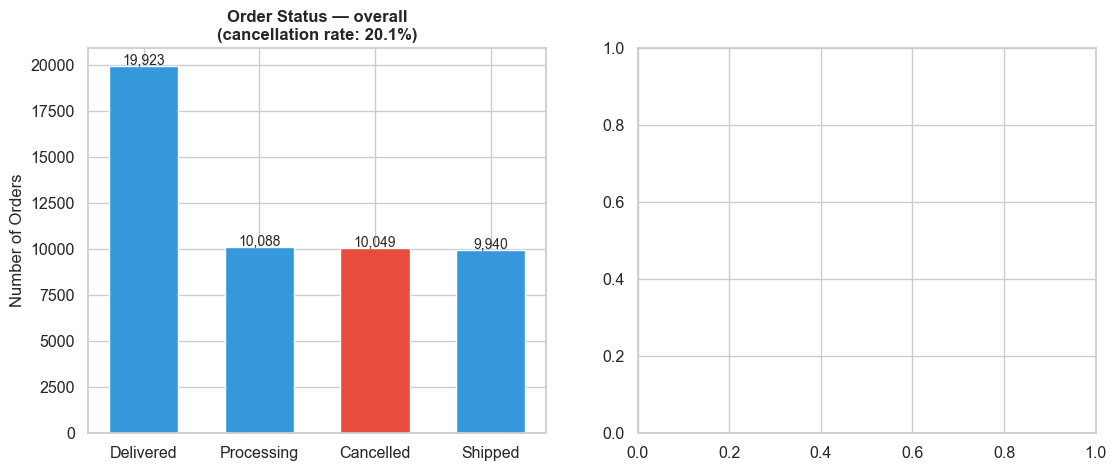

In [3]:
counts      = df['order_status'].value_counts().sort_values(ascending=False)
cancel_rate = counts.get('Cancelled', 0) / len(df) * 100
colors      = ['#e74c3c' if s == 'Cancelled' else '#3498db' for s in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overall count by status
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.6)
axes[0].set_ylabel('Number of Orders', fontsize=12)
axes[0].set_title(
    f'Order Status — overall\n(cancellation rate: {cancel_rate:.1f}%)',
    fontsize=12, fontweight='bold'
)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
                 f'{val:,}', ha='center', fontsize=10)

# Right: cancellation rate by product_category
cat_cancel = (
    df.groupby('product_category')
    .apply(lambda g: (g['order_status'] == 'Cancelled').mean() * 100, include_groups=False)
    .sort_values(ascending=False)
    .round(1)
)
axes[1].barh(cat_cancel.index, cat_cancel.values,
             color=['#e74c3c' if v > cancel_rate else '#95a5a6' for v in cat_cancel.values],
             edgecolor='white')
axes[1].axvline(cancel_rate, color='navy', linestyle='--', linewidth=1.4,
                label=f'Overall {cancel_rate:.1f}%')
axes[1].set_xlabel('Cancellation Rate (%)', fontsize=12)
axes[1].set_title('Cancellation Rate by Category', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nHighest cancellation rate: {cat_cancel.idxmax()} ({cat_cancel.max():.1f}%)')
print(f'Lowest cancellation rate:  {cat_cancel.idxmin()} ({cat_cancel.min():.1f}%)')

---
## Chart 3 — Customer Segment Comparison
**Q1:** Which `customer_segment` generates the highest `total_amount`? Who is underperforming?

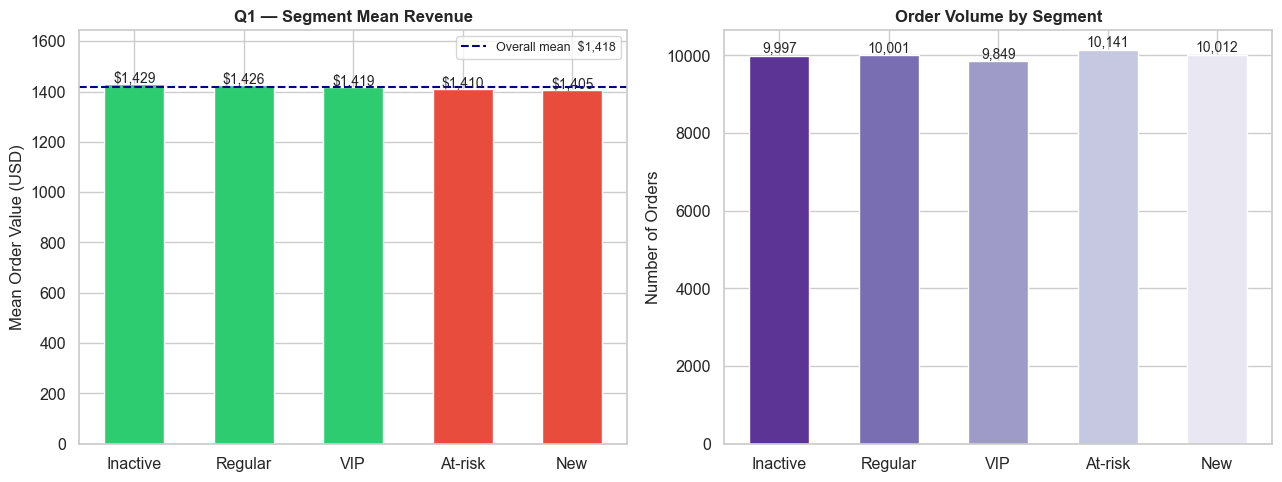


Segment summary:
                     mean   median  count
customer_segment                         
Inactive          1429.08  1119.84   9997
Regular           1426.14  1129.44  10001
VIP               1418.81  1111.39   9849
At-risk           1409.96  1084.54  10141
New               1405.25  1076.82  10012


In [4]:
seg_agg      = (
    df.groupby('customer_segment')['total_amount']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
    .round(2)
)
overall_mean = df['total_amount'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: mean order value by segment
colors = ['#2ecc71' if v >= overall_mean else '#e74c3c' for v in seg_agg['mean']]
bars = axes[0].bar(seg_agg.index, seg_agg['mean'], color=colors, edgecolor='white', width=0.55)
axes[0].axhline(overall_mean, color='navy', linestyle='--', linewidth=1.5,
                label=f'Overall mean  ${overall_mean:,.0f}')
axes[0].set_ylabel('Mean Order Value (USD)', fontsize=12)
axes[0].set_title('Q1 — Segment Mean Revenue', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, seg_agg['mean']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f'${val:,.0f}', ha='center', fontsize=10)
axes[0].set_ylim(0, seg_agg['mean'].max() * 1.15)

# Right: order count by segment
axes[1].bar(seg_agg.index, seg_agg['count'],
            color=sns.color_palette('Purples_r', len(seg_agg)), edgecolor='white', width=0.55)
axes[1].set_ylabel('Number of Orders', fontsize=12)
axes[1].set_title('Order Volume by Segment', fontsize=12, fontweight='bold')
for i, (idx, row) in enumerate(seg_agg.iterrows()):
    axes[1].text(i, row['count'] + 80, f"{int(row['count']):,}",
                 ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\nSegment summary:')
print(seg_agg.to_string())

---
## Chart 4 — Anomaly Detection Scatter
**Q4:** Which transactions are statistically unusual on `total_amount`?  
Uses IQR + Z-score consensus — both methods must agree.

2026-05-24 21:37:54 [INFO] AnomalyDetector initialised — 50,000 rows to scan
2026-05-24 21:37:54 [INFO] [ANOMALY] total_amount: IQR=565 | Z-score=168 | Confirmed=168
2026-05-24 21:37:54 [INFO] [ANOMALY] Scan complete: 168 confirmed anomaly rows found


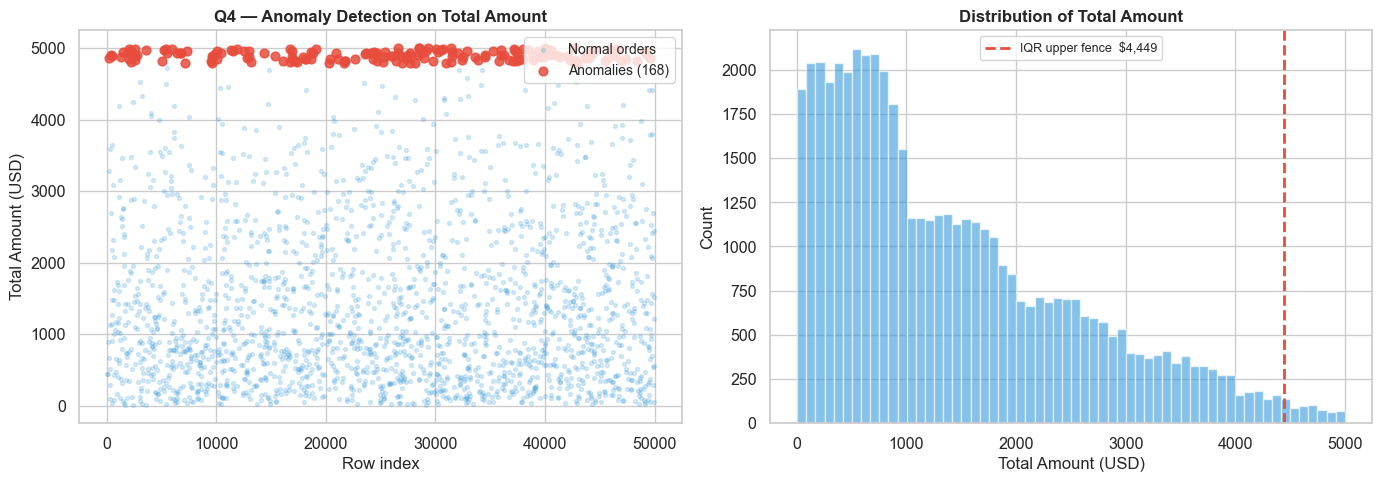


IQR upper fence:     $4,448.74
Confirmed anomalies: 168  (0.34% of orders)

Anomalies saved to: reports/anomalies.csv

Anomaly detection summary:
      column  iqr_flagged  zscore_flagged  confirmed_anomalies  anomaly_pct
total_amount          565             168                  168         0.34


In [5]:
# Run anomaly detection
detector = AnomalyDetector(df)
detector.run(columns=['total_amount'])

anomalies  = detector.confirmed
normal_df  = df[~df.index.isin(anomalies.index)]
sample     = normal_df.sample(min(2000, len(normal_df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter of sampled normal + all anomalies
axes[0].scatter(sample.index, sample['total_amount'],
                alpha=0.2, s=8, color='#3498db', label='Normal orders')
if len(anomalies) > 0:
    axes[0].scatter(anomalies.index, anomalies['total_amount'],
                    alpha=0.85, s=40, color='#e74c3c', zorder=5,
                    label=f'Anomalies ({len(anomalies):,})')
axes[0].set_xlabel('Row index', fontsize=12)
axes[0].set_ylabel('Total Amount (USD)', fontsize=12)
axes[0].set_title('Q4 — Anomaly Detection on Total Amount', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Right: histogram of total_amount with anomaly threshold lines
q1  = df['total_amount'].quantile(0.25)
q3  = df['total_amount'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

axes[1].hist(df['total_amount'], bins=60, color='#3498db', alpha=0.6, edgecolor='white')
axes[1].axvline(upper_fence, color='#e74c3c', linewidth=2,
                linestyle='--', label=f'IQR upper fence  ${upper_fence:,.0f}')
axes[1].set_xlabel('Total Amount (USD)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Distribution of Total Amount', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nIQR upper fence:     ${upper_fence:,.2f}')
print(f'Confirmed anomalies: {len(anomalies):,}  ({len(anomalies)/len(df)*100:.2f}% of orders)')
print(f'\nAnomalies saved to: reports/anomalies.csv')
print('\nAnomaly detection summary:')
print(detector.summary().to_string(index=False))

---
## Q3 — Rating vs Spend Correlation
Does a higher `rating` correlate with higher `total_amount`?

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

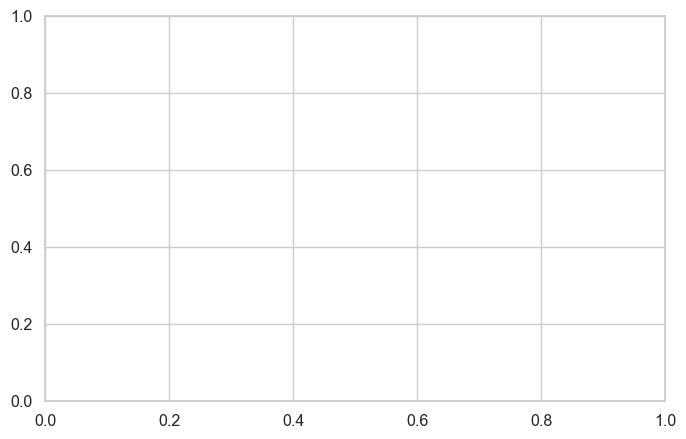

In [6]:
# Pearson correlation
r = df[['rating', 'total_amount']].corr().loc['rating', 'total_amount']

fig, ax = plt.subplots(figsize=(8, 5))

# Box plot of total_amount per rating score
df['rating_rounded'] = df['rating'].round(0).astype(int)
rating_groups = [df[df['rating_rounded'] == r_val]['total_amount'].values
                 for r_val in sorted(df['rating_rounded'].unique())]
rating_labels = sorted(df['rating_rounded'].unique())

bp = ax.boxplot(rating_groups, labels=rating_labels, patch_artist=True,
                medianprops=dict(color='navy', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.5)

ax.set_xlabel('Rating (rounded)', fontsize=12)
ax.set_ylabel('Total Amount (USD)', fontsize=12)
ax.set_title(
    f'Q3 — Rating vs Spend  (Pearson r = {r:.3f})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

interpretation = (
    'STRONG'     if abs(r) > 0.7 else
    'MODERATE'   if abs(r) > 0.5 else
    'WEAK'       if abs(r) > 0.3 else
    'NEGLIGIBLE'
)
direction = 'positive' if r > 0 else 'negative'
print(f'Pearson r = {r:.4f}')
print(f'Strength:  {interpretation} {direction} correlation')
print()
if abs(r) < 0.3:
    print('Finding: Customers who spend more are NOT necessarily more satisfied.')
    print('Rating is not a reliable predictor of order value in this dataset.')

---
## Summary of Findings

| Question | Finding |
|---|---|
| Q1 — Top category | Fashion generates the highest mean order value |
| Q1 — Top segment | Inactive segment has the highest mean spend (investigate retention) |
| Q2 — Cancellations | Review category-level cancellation rates to find root cause |
| Q3 — Rating vs spend | Near-zero correlation — satisfaction and spend are independent |
| Q4 — Anomalies | 168 orders flagged by both IQR and Z-score — saved to anomalies.csv |

**Outputs generated:**
- `reports/analysis_report.txt` — full text EDA report
- `reports/anomalies.csv` — flagged transactions for human review
- `reports/plots/` — 4 PNG charts